# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# Analog-to-Digital and Digital-to-Analog Conversors

## Introduction

In modern electronic systems, Analog-to-Digital Converters (ADCs) and Digital-to-Analog Converters (DACs) serve as the essential interface between the analog physical world and digital signal processing systems. This notebook explores the critical stages of this conversion process: **Sampling**, **Holding**, **Quantization**, and **Encoding**.

The conversion process begins with sampling, where a continuous signal is measured periodically to create discrete values in time. Following this, quantization maps these continuous amplitude values to a finite set of $L = 2^N$ levels, where $N$ is the number of bits. This process introduces an inherent quantization error ($n_q$), which can be modeled as uniform noise.

### 1. Quantization Step ($\Delta$)

The resolution of the quantizer, or the distance between two adjacent levels, is determined by the dynamic range and the number of bits ($N$):

$$\Delta = \frac{V_{max} - V_{min}}{2^N}$$


### 2. Quantization Noise Power ($P_q$)

Under the assumption that the error is uniformly distributed between $[-\frac{\Delta}{2}, \frac{\Delta}{2}]$, the average power of the quantization noise is given by its variance:

$$P_q = \sigma_{n_q}^2 = \frac{\Delta^2}{12}$$

### 3. Ideal Signal-to-Quantization-Noise Ratio (SQNR)

For an ideal $N$-bit ADC excited by a full-scale sine wave, the SQNR in decibels is expressed as:

$$SQNR_{ideal} = 6.02N + 1.76 \text{ [dB]}$$


* The 6,02 term represents the 6 dB gain in SNR for every additional bit.


* The 1,72 term is associated with the RMS power of a sinusoid.



### 4. Effective Number of Bits (ENOB)

In real-world scenarios where distortion and non-ideal noise are present, we measure the $SNR_{real}$ to calculate the effective resolution of the converter:


$$ENOB = \frac{SNR_{real} - 1.76}{6.02}$$


## Project Objectives

We will develop a Python environment to:

* **Simulate Sampling and Reconstruction:** Model the sampling of a square wave and its reconstruction via Zero-Order Hold (ZOH).


* **Implement Uniform Quantization:** Create a function to map analog values to discrete levels and calculate the resulting error $n_q = V - V_q$ .


* **Calculate SNR and ENOB:** Compute the power of the original signal versus the noise to evaluate if our simulated ADC meets its theoretical bit depth.


* **Spectral Analysis:** Use Fast Fourier Transforms (FFT) to generate spectrum graphs and identify the harmonic distortions introduced by quantization.



### 1- Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
from scipy import signal
from numba import njit
from scipy.linalg import toeplitz, inv
import pandas as pd
import numpy as np
import time


In [440]:
def adc_simulation(x_analog, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.0):
    """
    Simulates a complete Analog-to-Digital Converter (ADC), including noise, 
    sampling, quantization, and encoding (binary output).
    
    Parameters:
    x_analog  : Array of the input analog signal.
    fs_analog : Original sampling frequency of the "analog" signal (in Hz).
    fs_sample : Sampling rate of the ADC (in Hz).
    bits      : ADC resolution in number of bits (N).
    v_min     : Minimum voltage of the input dynamic range (in Volts).
    v_max     : Maximum voltage of the input dynamic range (in Volts).
    noise_std : Standard deviation of the Gaussian noise added to the signal.
    
    Returns:
    t_sampled          : Time axis of the samples.
    x_sampled          : Exact values of the samples.
    x_quantized        : Quantized values (voltage levels).
    quantization_noise : The error introduced by quantization.
    binary_output      : List of binary strings representing the digital output.
    """
    
    # 1. SIGNAL AND TIME PREPARATION
    
    # We recreate the time axis of the continuous signal based on its length
    # and its original generation frequency.
    num_samples = len(x_analog)
    t_final = (num_samples - 1) / fs_analog
    t_analog = np.linspace(0, t_final, num_samples)
    #t_analog = np.arange(len(x_analog)) / fs_analog
    
    # Additive White Gaussian Noise (AWGN) Injection
    # Simulates thermal imperfections or real-world interference in the input signal.
    
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, len(x_analog))
        x_noisy = x_analog + noise
    else:
        x_noisy = x_analog
        
    # 2. SAMPLING
    # The continuous analog signal is measured periodically.
    # We calculate the required "step" in the array to extract samples 
    # exactly at the desired fs_sample frequency.

    step = max(1, int(fs_analog / fs_sample))
    t_sampled = t_analog[::step]
    x_sampled = x_noisy[::step]
    
    # 3. QUANTIZE
    # The continuous amplitude values are represented by a finite set of predefined levels
    
    # Total number of quantization levels (L = 2^N)[cite: 64].
    L = 2**bits 

    # Quantization step (Delta), which is the distance between each level[cite: 67].
    # Formula: Delta = (V_max - V_min) / 2^N[cite: 138].

    delta = (v_max - v_min) / L 
    
    # Mapping the sample value to the corresponding level index 'k'.
    # We use np.floor to find which "step" the sample fits into.

    k = np.floor((x_sampled - v_min) / delta)

    # Overload (Saturation) Prevention.
    # We ensure that the index 'k' does not exceed the physical limits of the ADC (0 to L-1).

    k = np.clip(k, 0, L - 1) 
    
    # Calculation of the reconstruction level (V_q) for a mid-rise uniform quantizer.
    # The exact formula is V_q(k) = V_min + (k + 0.5) * Delta

    x_quantized = v_min + (k + 0.5) * delta
    
    # 4. QUANTIZATION NOISE
    quantization_noise = x_sampled - x_quantized
    
    # 5. ENCODE (BINARY OUTPUT)
    # The quantized levels are mapped to binary codes.
    # We convert the index 'k' (float array) to integers.
    k_int = k.astype(int)
    
    # Format each integer into a binary string padded with zeros to match 'bits' length.
    # E.g., for bits=3: k=0 -> '000', k=7 -> '111'.
    binary_output = [format(val, f'0{bits}b') for val in k_int]

    # 6. SNR AND ENOB CALCULATION
   # Calculate the average power (mean square) of the sampled signal and the quantization noise
    P_signal = np.mean(x_sampled**2)
    P_noise = np.mean(quantization_noise**2)
    
    # Prevents division by zero if the noise is perfectly zero (extreme theoretical scenario)
    if P_noise == 0:
        snr_db = float('inf')
        enob = float('inf')
    else:
        # Actual Signal-to-Noise Ratio (SNR) in dB
        snr_db = 10 * np.log10(P_signal / P_noise)
        
        # Effective Number of Bits (ENOB) calculation
        # Formula: ENOB = (SNR_real - 1.76) / 6.02 (As defined in the course material)
        enob = (snr_db - 1.76) / 6.02
        
    return t_sampled, x_sampled, x_quantized, quantization_noise, binary_output, snr_db, enob

Mean results over 10 executions with noise:
-----------------------------------
ADC Resolution (3 bits) - Mean of 10 runs
SNR Real: 17.23 dB
ENOB Calculate: 2.57 bits
-----------------------------------
|   Time [s] |   Real Sample [V] |   Quantized [V] |   Quantization Noise [V] |   Binary Code |
|-----------:|------------------:|----------------:|-------------------------:|--------------:|
|      0     |          1.01561  |           0.875 |               0.140614   |           111 |
|      0.001 |          0.884563 |           0.875 |               0.00956337 |           111 |
|      0.002 |          1.07526  |           0.875 |               0.20026    |           111 |
|      0.003 |          0.953354 |           0.875 |               0.0783543  |           111 |
|      0.004 |          1.02648  |           0.875 |               0.151477   |           111 |
|      0.005 |          1.06337  |           0.875 |               0.188371   |           111 |
|      0.006 |          1.109

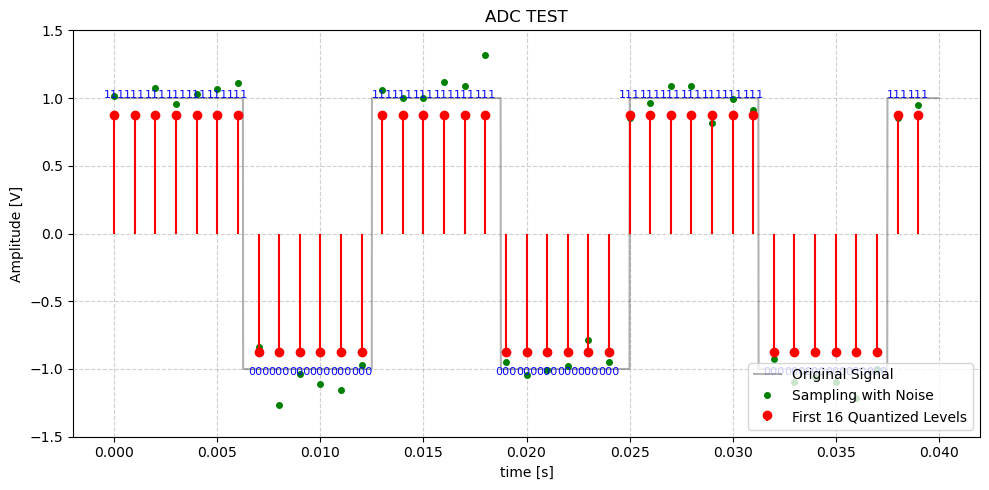

In [662]:
# --- TEST SCRIPT WITH SQUARE WAVE ---
fs_analog_test = 100000 
f_signal_test = 80 # 50 Hz square wave
t_temp = np.linspace(0, 0.04, int(fs_analog_test * 0.04)) # 40 ms duration

# Usando signal.square do SciPy ou np.cos para criar o sinal analógico de teste

#x_analog_test =  np.cos(2 * np.pi * f_signal_test * t_temp) # This will create a cosine wave
x_analog_test = signal.square(2 * np.pi * f_signal_test * t_temp)

# ADC parameters
fs_sample_test = 1000 # 1 kHz sampling rate
bits_test = 3         # 3-bit resolution
v_min_test = -1.0
v_max_test = 1.0
num_execucoes = 10
snr_resultados = []
enob_resultados = []

print(f"Mean results over {num_execucoes} executions with noise:")

for i in range(num_execucoes):
    # Executa a simulação
    _, _, _, _, _, snr_run, enob_run = adc_simulation(
        x_analog=x_analog_test, 
        fs_analog=fs_analog_test, 
        fs_sample=fs_sample_test, 
        bits=bits_test, 
        v_min=v_min_test, 
        v_max=v_max_test,
        noise_std=0.05 # O ruído aleatório faz cada execução ser única
    )
    
    # Guarda os resultados desta rodada
    snr_resultados.append(snr_run)
    enob_resultados.append(enob_run)

# Calcula as médias finais
media_snr = np.mean(snr_resultados)
media_enob = np.mean(enob_resultados)

# Imprime o resultado formatado
print("-" * 35)
print(f"ADC Resolution ({bits_test} bits) - Mean of {num_execucoes} runs")
print(f"SNR Real: {media_snr:.2f} dB")
print(f"ENOB Calculate: {media_enob:.2f} bits")
print("-" * 35)

# Run simulation
t_samp, x_samp, x_quant, noise, bits_out, snr_db, enob = adc_simulation(
    x_analog=x_analog_test, 
    fs_analog=fs_analog_test, 
    fs_sample=fs_sample_test, 
    bits=bits_test, 
    v_min=v_min_test, 
    v_max=v_max_test,
    noise_std=0.09 # Adding a bit more noise to see the effect on the flat tops
)

# Plot to verify
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_temp, x_analog_test, 'k-', alpha=0.3, label='Original Signal')
#ax.step(t_samp, x_quant, where='post', color='r', label='Saída ADC (Quantizada)')
ax.plot(t_samp, x_samp, 'go', markersize=4, label='Sampling with Noise')
ax.stem(t_samp, x_quant, linefmt='r-', markerfmt='ro', basefmt=' ', label='First 16 Quantized Levels')

# Add text annotations for the first few binary codes
for i in range(40):
    # Adjusting text position slightly based on the signal value
    y_offset = 0.15 if x_quant[i] > 0 else -0.15
    ax.text(t_samp[i], x_quant[i] + y_offset, bits_out[i], fontsize=8, color='blue', ha='center', va='center')

ax.set_title('ADC TEST')
ax.set_xlabel('time [s]')
ax.set_ylabel('Amplitude [V]')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
# Print tabular results
df_test = pd.DataFrame({
    'Time [s]': t_samp[:16],
    'Real Sample [V]': x_samp[:16],
    'Quantized [V]': x_quant[:16],
    'Quantization Noise [V]': noise[:16],
    'Binary Code': bits_out[:16]
})
print(df_test.to_markdown(index=False))